In [26]:
"""Analysis of reasoning token lengths for base model coding inference."""

import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

In [27]:
# --- configuration ---

FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# pre-computed stats live here (generated by scripts/compute_stats.py)
OVERFLOW_DIR = Path("../output/token_stats")

# token budgets to plot — one figure is produced per budget
# BUDGETS: list[int] = [32768, 16384, 8192]
BUDGETS_TO_DISPLAY: list[int] = [32768]

# code benchmarks only — grouped by domain.
# each entry: display label → (inference file stem base, dataset jsonl path)
# the budget is appended at runtime (e.g. "evalplus_greedy_mx" + "32768")
DATASETS: dict[str, dict[str, tuple[str, str]]] = {
    "code": {
        "evalplus": ("evalplus_greedy_mx", "code/evalplus.jsonl"),
        "livecodebench": ("livecodebench_greedy_mx", "code/livecodebench.jsonl"),
        "bigcodebench": ("bigcodebench_greedy_mx", "code/bigcodebench.jsonl"),
        "code_contests": ("code_contests_greedy_mx", "code/code_contests.jsonl"),
    },
    "crux": {
        "cruxeval_i": ("cruxeval_i_greedy_mx", "crux/cruxeval_i.jsonl"),
        "cruxeval_o": ("cruxeval_o_greedy_mx", "crux/cruxeval_o.jsonl"),
    },
}

# vibrant palette: ColorBrewer Set1 with yellow (#5) replaced by cyan and
# grey (#8) replaced by deep pink, for better on-white visibility
_P = [
    "#E41A1C",  # red
    "#377EB8",  # blue
    "#4DAF4A",  # green
    "#984EA3",  # purple
    "#FF7F00",  # orange
    "#00BCD4",  # cyan  (replaces Set1 yellow)
    "#A65628",  # brown
    "#F781BF",  # pink
    "#FF4081",  # deep pink  (replaces Set1 grey)
]

# colour groups by model family:
#   qwen3 models → blue / teal / cyan (similar, distinct)
#   ocr / or     → pink / purple
#   olmo / llama → orange / brown
SERIES: dict[str, dict] = {
    "qwen3_8b": {"label": "Qwen3-8B", "model_key": "qwen3-8b", "colour": "#377EB8"},
    "qwen3_14b": {"label": "Qwen3-14B", "model_key": "qwen3-14b", "colour": "#009688"},
    "qwen3_32b": {"label": "Qwen3-32B", "model_key": "qwen3-32b", "colour": "#00BCD4"},
    "olmo_3_7b": {"label": "OLMo3-7B", "model_key": "olmo-3-7b", "colour": "#FF7F00"},
    "llama_r1_8b": {
        "label": "Llama-R1-8B",
        "model_key": "llama-r1-8b",
        "colour": "#A65628",
    },
    "ocr_7b": {"label": "OCR-7B", "model_key": "ocr-7b", "colour": "#F781BF"},
    "or_7b": {"label": "OR-7B", "model_key": "or-7b", "colour": "#984EA3"},
}

# human-readable subplot titles for each dataset
DATASET_DISPLAY_NAMES: dict[str, str] = {
    "evalplus": "EvalPlus",
    "livecodebench": "LiveCodeBench",
    "bigcodebench": "BigCodeBench",
    "code_contests": "CodeContests",
    "cruxeval_i": "CRUX-Input",
    "cruxeval_o": "CRUX-Output",
}

# colours used when group_by="model" — one vibrant colour per dataset
DATASET_COLOURS: dict[str, str] = {
    "evalplus": _P[0],
    "livecodebench": _P[1],
    "bigcodebench": _P[2],
    "code_contests": _P[3],
    "cruxeval_i": _P[4],
    "cruxeval_o": _P[5],
}

In [28]:
def load_series_results(
    series_keys: list[str],
    datasets: dict[str, dict[str, tuple[str, str]]],
    budget: int,
) -> dict[str, dict[str, dict]]:
    """Load pre-computed token stats from output/token_stats/ for a given budget.

    Run scripts/compute_stats.py first to generate these files.
    Stats are stored one file per model: output/token_stats/{model_key}.json,
    with all datasets nested under a "datasets" key, keyed by run key
    (e.g. "evalplus_greedy_mx32768").
    Missing files or datasets are skipped with a warning.

    Returns a nested dict: series_key → dataset_label → stats dict containing
    reasoning_token_counts, budget_pct, pass_at_1, and max_tokens.
    """
    # flatten the nested datasets dict to {label: (stem_base, jsonl_path)}
    flat_datasets: dict[str, tuple[str, str]] = {
        label: entry
        for domain_ds in datasets.values()
        for label, entry in domain_ds.items()
    }

    results: dict[str, dict[str, dict]] = {}
    for series_key in series_keys:
        results[series_key] = {}
        model_key = SERIES[series_key]["model_key"]

        # one file per model holds all datasets and budgets
        stats_path = OVERFLOW_DIR / f"{model_key}.json"
        if not stats_path.exists():
            print(f"  [skip] missing {stats_path} — run scripts/compute_stats.py first")
            continue

        with open(stats_path) as f:
            model_data = json.load(f)

        all_datasets = model_data.get("datasets", {})

        for ds_label, (ds_base, _) in flat_datasets.items():
            # datasets are keyed by the full inference file stem (e.g. "evalplus_greedy_mx32768")
            run_key = f"{ds_base}{budget}"
            stats = all_datasets.get(run_key)
            if stats is None:
                print(
                    f"  [skip] {series_key}/{run_key} not in {stats_path} "
                    f"— run scripts/compute_stats.py first"
                )
                continue

            results[series_key][ds_label] = {
                "reasoning_token_counts": stats["reasoning_token_counts"],
                "budget_pct": stats["budget_pct"],
                "pass_at_1": stats["pass_at_1"],
                "max_tokens": stats["max_tokens"],
            }

            counts = stats["reasoning_token_counts"]
            pcts = stats["budget_pct"]
            pass_at_1 = stats["pass_at_1"]
            print(
                f"  {series_key} / {run_key}: "
                f"n={len(counts)}, "
                f"median={int(np.median(counts)):,} reasoning tokens, "
                f"median budget={np.median(pcts):.1f}%, "
                f"pass@1={100 * pass_at_1:.1f}%"
            )

    return results


# load results for every budget upfront — plot cells select the budget they need
all_results: dict[int, dict[str, dict[str, dict]]] = {}
for budget in BUDGETS_TO_DISPLAY:
    print(f"\nloading results for budget={budget:,}...")
    all_results[budget] = load_series_results(
        series_keys=list(SERIES.keys()),
        datasets=DATASETS,
        budget=budget,
    )


loading results for budget=32,768...
  qwen3_8b / evalplus_greedy_mx32768: n=542, median=2,188 reasoning tokens, median budget=6.7%, pass@1=42.6%
  qwen3_8b / livecodebench_greedy_mx32768: n=342, median=16,689 reasoning tokens, median budget=50.9%, pass@1=36.0%
  qwen3_8b / bigcodebench_greedy_mx32768: n=1140, median=4,464 reasoning tokens, median budget=13.6%, pass@1=0.0%
  qwen3_8b / code_contests_greedy_mx32768: n=165, median=31,490 reasoning tokens, median budget=100.0%, pass@1=27.3%
  qwen3_8b / cruxeval_i_greedy_mx32768: n=800, median=2,495 reasoning tokens, median budget=7.6%, pass@1=85.8%
  qwen3_8b / cruxeval_o_greedy_mx32768: n=800, median=770 reasoning tokens, median budget=2.4%, pass@1=88.5%
  qwen3_14b / evalplus_greedy_mx32768: n=542, median=1,902 reasoning tokens, median budget=5.8%, pass@1=51.7%
  qwen3_14b / livecodebench_greedy_mx32768: n=342, median=12,161 reasoning tokens, median budget=37.1%, pass@1=47.7%
  qwen3_14b / bigcodebench_greedy_mx32768: n=1140, median=3

In [29]:
FONT_SIZE = 11  # axis labels
TICK_SIZE = 10  # x-tick and y-tick labels
OVERFLOW_SIZE = 11  # overflow % annotation above the 100% line
TITLE_SIZE = 13  # subplot title — matches notebook 03


def _draw_violin_axes(
    ax: plt.Axes,
    data_per_violin: list[list],
    labels: list[str],
    colours: list[str],
    overflow_pcts: list[float] | None,
    title: str,
    hline: float | None,
    ylim: tuple | None,
    yformatter,
) -> None:
    """Draw violin plots for one subplot with median lines and overflow annotations.

    The subplot title is placed above the axes. No y-axis label is shown; tick
    values appear on the left column (default) and the right column (configured
    in _build_plot after this call).
    When overflow_pcts is provided, the overflow percentage for each violin is
    printed above the hline in the headroom above 100%.
    """
    positions = list(range(1, len(data_per_violin) + 1))

    parts = ax.violinplot(
        data_per_violin,
        positions=positions,
        showmedians=True,
        showextrema=True,
    )

    for pc, colour in zip(parts["bodies"], colours):
        pc.set_facecolor(colour)
        pc.set_alpha(0.85)

    # make median, whisker and bar lines black to match the ci error bars
    for element in ("cmedians", "cmaxes", "cmins", "cbars"):
        parts[element].set_color("black")
        parts[element].set_linewidth(1.2)

    if hline is not None:
        ax.axhline(hline, color="red", linestyle="--", linewidth=2.5)

    # print reasoning overflow % in the headroom above the 100% line
    if hline is not None and overflow_pcts is not None and ylim is not None:
        text_y = (hline + ylim[1]) / 2
        for x_pos, pct in zip(positions, overflow_pcts):
            ax.text(
                x_pos,
                text_y,
                f"{pct:.1f}%",
                ha="center",
                va="center",
                fontsize=OVERFLOW_SIZE,
                fontweight="bold",
                color="black",
            )

    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=TICK_SIZE)
    ax.set_title(title, fontsize=TITLE_SIZE, fontweight="bold")

    if ylim is not None:
        ax.set_ylim(ylim)
        # suppress any tick that lands in the headroom above the data range
        ax.set_yticks([t for t in ax.get_yticks() if t < ylim[1]])
    else:
        ax.set_ylim(bottom=0)

    if yformatter is not None:
        ax.yaxis.set_major_formatter(yformatter)

    ax.tick_params(axis="y", labelsize=TICK_SIZE)
    ax.grid(axis="y", alpha=0.5, linewidth=1.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def _build_plot(
    series_keys: list[str],
    loaded_results: dict,
    datasets: dict,
    group_by: str,
    get_data: callable,
    get_overflow_pct: callable,
    hline: float | None,
    ylim: tuple | None,
    yformatter,
    save_path: "Path",
    ylabel: str | None = None,
) -> None:
    """Build and save a violin plot figure in a 2-column grid.

    group_by="dataset": one subplot per dataset, one violin per series/model.
    group_by="model":   one subplot per series/model, one violin per dataset.
    Subplots are arranged 2 per row, matching the layout of notebook 03.
    Right-column axes show tick values on their right side instead of a y-label.
    Rows with no loaded data are silently skipped.
    Pass get_overflow_pct=None to suppress the overflow annotation.
    """
    all_ds_labels: list[str] = [
        ds_label for domain_ds in datasets.values() for ds_label in domain_ds
    ]

    rows: list[dict] = []

    if group_by == "dataset":
        for ds_label in all_ds_labels:
            row: dict = {
                "title": DATASET_DISPLAY_NAMES[ds_label],
                "labels": [],
                "colours": [],
                "data": [],
                "overflow_pcts": [] if get_overflow_pct is not None else None,
            }
            for series_key in series_keys:
                ds_results = loaded_results.get(series_key, {}).get(ds_label)
                if ds_results is None:
                    continue
                row["labels"].append(SERIES[series_key]["label"])
                row["colours"].append(SERIES[series_key]["colour"])
                row["data"].append(get_data(ds_results))
                if get_overflow_pct is not None:
                    row["overflow_pcts"].append(get_overflow_pct(ds_results))
            if row["data"]:
                rows.append(row)

    elif group_by == "model":
        for series_key in series_keys:
            row = {
                "title": SERIES[series_key]["label"].replace("\n", " "),
                "labels": [],
                "colours": [],
                "data": [],
                "overflow_pcts": [] if get_overflow_pct is not None else None,
            }
            for ds_label in all_ds_labels:
                ds_results = loaded_results.get(series_key, {}).get(ds_label)
                if ds_results is None:
                    continue
                row["labels"].append(DATASET_DISPLAY_NAMES[ds_label])
                row["colours"].append(DATASET_COLOURS[ds_label])
                row["data"].append(get_data(ds_results))
                if get_overflow_pct is not None:
                    row["overflow_pcts"].append(get_overflow_pct(ds_results))
            if row["data"]:
                rows.append(row)

    else:
        raise ValueError(f"group_by must be 'dataset' or 'model', got {group_by!r}")

    if not rows:
        print(f"  [skip] no data to plot for {save_path.name}")
        return

    # 2-column grid matching notebook 03's layout
    n_cols = 2
    n_rows = (len(rows) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(13, 3.0 * n_rows),
        sharey=True,
        squeeze=False,
    )
    flat_axes = axes.flatten()

    for idx, row in enumerate(rows):
        ax = flat_axes[idx]
        _draw_violin_axes(
            ax=ax,
            data_per_violin=row["data"],
            labels=row["labels"],
            colours=row["colours"],
            overflow_pcts=row["overflow_pcts"],
            title=row["title"],
            hline=hline,
            ylim=ylim,
            yformatter=yformatter,
        )
        if ylabel is not None:
            ax.set_ylabel(ylabel, fontsize=FONT_SIZE)
        # right column: show tick values on the right side instead of the left
        if idx % n_cols == 1:
            ax.tick_params(
                axis="y", labelleft=True, labelright=False, labelsize=TICK_SIZE
            )
            ax.spines["right"].set_visible(True)

    # hide any spare axes when the number of rows is odd
    for ax in flat_axes[len(rows) :]:
        ax.set_visible(False)

    fig.tight_layout(h_pad=2, w_pad=2)
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"saved {save_path}")
    plt.show()


def plot_token_lengths(
    series_keys: list[str],
    loaded_results: dict,
    datasets: dict,
    save_path: "Path",
    group_by: str = "dataset",
) -> None:
    """Plot violin distributions of raw reasoning token counts.

    One subplot per group (dataset or model), arranged in a 2-column grid.
    """

    def get_data(ds_results: dict) -> list[int]:
        return ds_results["reasoning_token_counts"]

    _build_plot(
        series_keys=series_keys,
        loaded_results=loaded_results,
        datasets=datasets,
        group_by=group_by,
        get_data=get_data,
        get_overflow_pct=None,
        hline=None,
        ylim=None,
        yformatter=mticker.FuncFormatter(lambda x, _: f"{int(x):,}"),
        save_path=save_path,
    )


def plot_budget_pct(
    series_keys: list[str],
    loaded_results: dict,
    datasets: dict,
    save_path: "Path",
    group_by: str = "dataset",
) -> None:
    """Plot violin distributions of reasoning as % of the generation token budget.

    Uses the pre-computed budget_pct values (relative to each run's max_tokens).
    Responses with no answer that hit the length limit are pinned at 100%.
    The reasoning overflow rate (% of samples at 100%) is printed above the 100%
    line in the headroom at the top of each subplot.
    """

    def get_data(ds_results: dict) -> list[float]:
        return ds_results["budget_pct"]

    def get_overflow_pct(ds_results: dict) -> float:
        # reasoning overflow: fraction of samples that consumed the full budget
        pcts = ds_results["budget_pct"]
        return 100.0 * sum(1 for x in pcts if x >= 100.0) / len(pcts)

    _build_plot(
        series_keys=series_keys,
        loaded_results=loaded_results,
        datasets=datasets,
        group_by=group_by,
        get_data=get_data,
        get_overflow_pct=get_overflow_pct,
        hline=100,
        ylim=(0, 120),
        yformatter=mticker.FuncFormatter(lambda x, _: f"{int(x)}"),
        ylabel="Output reasoning (%)",
        save_path=save_path,
    )

saved ../figures/02_budget.png


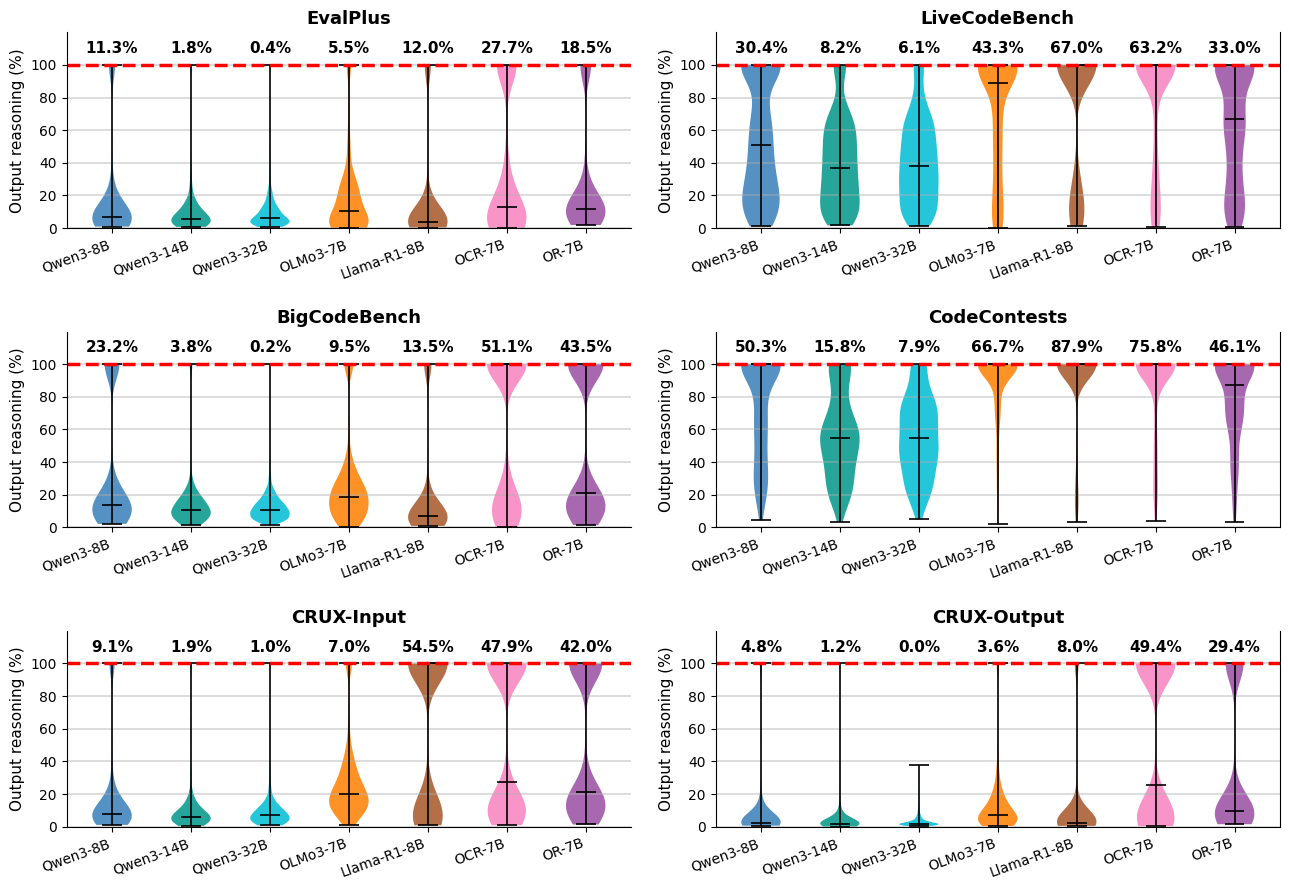

In [30]:
# --- budget % used for reasoning ---
# each violin shows how much of the generation budget was consumed for reasoning.
# one figure is saved per token budget (8k, 16k, 32k).

ALL_SERIES = list(SERIES.keys())

for budget in BUDGETS_TO_DISPLAY:
    plot_budget_pct(
        series_keys=ALL_SERIES,
        loaded_results=all_results[budget],
        datasets=DATASETS,
        group_by="dataset",
        save_path=FIGURES_DIR / "02_budget.png",
    )